# 1D Hubbard playground

Generated from `docs/source/tutorial/hubbard_1d.md` for local testing. This file is untracked and not intended for commit.

# 1D Hubbard model

## Background physics

To show the basic functionality of the package, we consider a simple interacting electronic system: a 1D chain of sites that allow nearest-neighbor tunneling with strength $t$ and on-site repulsion $U$ between two electrons if they are on the same site.
Such a model is known as the 1D [Hubbard model](https://en.wikipedia.org/wiki/Hubbard_model) and is useful for understanding the onset of insulating phases in interacting metals.

To begin, we first consider the second quantized form of the non-interacting Hamiltonian.
Because we expect the interacting ground state to be antiferromagnetic, we build a two-atom cell and name the two sublattices $A$ and $B$.
These sublattices are identical to each other in the non-interacting case $U=0$.
The non-interacting Hamiltonian reads:

$$
\hat{H_0} = - t \sum_\sigma \sum_i \left(c_{i, B, \sigma}^{\dagger}c_{i, A, \sigma} + c_{i, A, \sigma}^{\dagger}c_{i+1, B, \sigma} + \textrm{h.c}\right).
$$

where $\textrm{h.c}$ is the hermitian conjugate, $\sigma$ denotes spin ($\uparrow$ or $\downarrow$) and $c_{i, A, \sigma}^{\dagger}$ creates an electron with spin $\sigma$ in unit cell $i$ of sublattice $A$.
Next up, is the interacting part of the Hamiltonian:

$$
\hat{V} = U \sum_i \left(n_{i, A, \uparrow} n_{i, A, \downarrow} + n_{i, B, \uparrow} n_{i, B, \downarrow}\right).
$$

where $n_{i, A, \sigma} = c_{i, A, \sigma}^{\dagger}c_{i, A, \sigma}$ is the number operator for sublattice $A$ and spin $\sigma$.
The total Hamiltonian is then $\hat{H} = \hat{H_0} + \hat{V}$.
With the model defined, we can now proceed to input the Hamiltonian into the package and solve it using the mean-field approximation.

## Problem definition

### Non-interacting Hamiltonian

First, let's get the basic imports out of the way.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import meanfi
from scipy.optimize import anderson

tutorial_model_kwargs = dict(
    kT=0,
    charge_tol=1e-4,
    density_atol=1e-4,
    scf_tol=1e-3,
)

Now let us translate the non-interacting Hamiltonian $\hat{H_0}$ defined above into the basic input format for the package: a **tight-binding dictionary**.
The tight-binding dictionary is a python dictionary where the keys are tuples of integers representing the hopping vectors and the values are the hopping matrices.
For example, a key `(0,)` represents the onsite term in one dimension and a key `(1,)` represents the hopping a single unit cell to the right.
In two dimensions a key `(0,0)` would represent the onsite term and `(1,0)` would represent hopping to the right in the direction of the first reciprocal lattice vector.
In the case of our 1D Hubbard model, we only have an onsite term and hopping a single unit cell to the left and right.
Thus our non-interacting Hamiltonian  becomes:

In [32]:
hopp = np.kron(np.array([[0, 1], [0, 0]]), np.eye(2))
h_0 = {(0,): hopp + hopp.T.conj(), (1,): hopp, (-1,): hopp.T.conj()}

Here `hopp` is the hopping matrix which we define as a kronecker product between sublattice and spin degrees of freedom: `np.array([[0, 1], [0, 0]])` corresponds to the hopping between sublattices and `np.eye(2)` leaves the spin degrees of freedom unchanged.
In the corresponding tight-binding dictionary `h_0`, the key `(0,)` contains hopping within the unit cell and the keys `(1,)` and `(-1,)` correspond to the hopping between the unit cells to the right and left respectively.

To verify the validity of `h_0`, we evaluate it in the reciprocal space using the `meanfi.tb.transforms.tb_to_kgrid`, then diagonalize it and plot the band structure:

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/var/folders/48/6y5gb3f12mzc7jw_vmbm6y0c0000gp/T/ipykernel_81592/2736794707.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([0, np.pi, 2 * np.pi], ["$0$", "$\pi$", "$2\pi$"])
/var/folders/48/6y5gb3f12mzc7jw_vmbm6y0c0000gp/T/ipykernel_81592/2736794707.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([0, np.pi, 2 * np.pi], ["$0$", "$\pi$", "$2\pi$"])


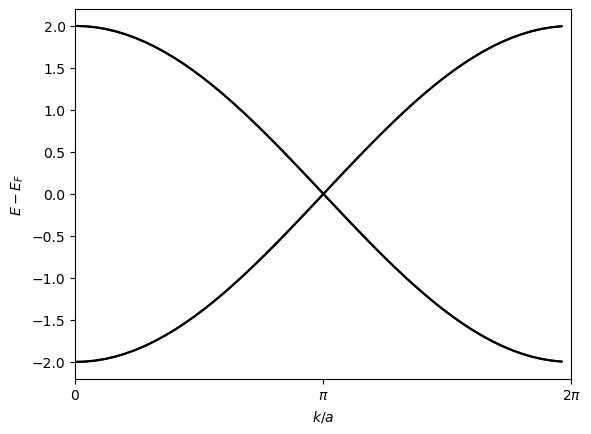

In [33]:
nk = 50  # number of k-points
ks = np.linspace(0, 2 * np.pi, nk, endpoint=False)
hamiltonians_0 = meanfi.tb_to_kgrid(h_0, nk)

vals, vecs = np.linalg.eigh(hamiltonians_0)
plt.plot(ks, vals, c="k")
plt.xticks([0, np.pi, 2 * np.pi], ["$0$", "$\pi$", "$2\pi$"])
plt.xlim(0, 2 * np.pi)
plt.ylabel("$E - E_F$")
plt.xlabel("$k / a$")
plt.show()

which seems metallic as expected.

### Interaction Hamiltonian

We now proceed to define the interaction Hamiltonian $\hat{V}$.
To achieve this, we utilize the same tight-binding dictionary format as before.
Because the interaction Hamiltonian is on-site, it must be defined only for the key `(0,)` and only for electrons on the same sublattice with opposite spins.
Based on the kronecker product structure we defined earlier, the interaction Hamiltonian is:

In [34]:
U = 2
s_x = np.array([[0, 1], [1, 0]])
h_int = {
    (0,): U * np.kron(np.eye(2), s_x),
}

Here `s_x` is the Pauli matrix acting on the spin degrees of freedom, which ensures that the interaction is only between electrons with opposite spins whereas the `np.eye(2)` ensures that the interaction is only between electrons on the same sublattice.

### Putting it all together

To combine the non-interacting and interaction Hamiltonians, we use the `meanfi.model.Model` class.
In addition to the Hamiltonians, we also need to specify the filling of the system --- the number of electrons per unit cell.

In [35]:
filling = 2
full_model = meanfi.Model(h_0, h_int, filling, **tutorial_model_kwargs)

The object `full_model` now contains all the information needed to solve the mean-field problem.

## Solving the mean-field problem

To find a mean-field solution, we first require a starting guess.
In cases where the non-interacting Hamiltonian is highly degenerate, there exists several possible mean-field solutions, many of which are local and not global minima of the energy landscape.
Therefore, the choice of the initial guess can significantly affect the final solution depending on the energy landscape.
Here the problem is simple enough that we can generate a random guess for the mean-field solution through the `meanfi.tb.utils.guess_tb` function.
It creates a random Hermitian tight-binding dictionary based on the hopping keys provided and the number of degrees of freedom within the unit cell.
Because the mean-field solution cannot contain hoppings longer than the interaction itself, we use `h_int` keys as an input to `meanfi.tb.utils.guess_tb`.
To keep the adaptive-quadrature tutorial practical without changing the plots themselves, we use a modestly
larger finite temperature and slightly looser tolerances through `tutorial_model_kwargs`. The default solver
uses internal linear mixing, which is sufficient for this small example. For the wider phase-diagram sweep
below we pass `scipy.optimize.anderson` explicitly through the `optimizer=` hook.

In [36]:
filling = 2
full_model = meanfi.Model(h_0, h_int, filling, **tutorial_model_kwargs)
guess = meanfi.guess_tb(frozenset(h_int), ndof=4)
mf_sol = meanfi.solver(
    full_model,
    guess,
    max_scf_steps=1000,
    optimizer_kwargs={"alpha": 0.5},
)


The `meanfi.solvers.solver` function returns only the mean-field correction to the non-interacting Hamiltonian in the same tight-binding dictionary format.
To get the full Hamiltonian, we add the mean-field correction to the non-interacting Hamiltonian and plot the band structure just as before:

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/var/folders/48/6y5gb3f12mzc7jw_vmbm6y0c0000gp/T/ipykernel_81592/2193080342.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([0, np.pi, 2 * np.pi], ["$0$", "$\pi$", "$2\pi$"])
/var/folders/48/6y5gb3f12mzc7jw_vmbm6y0c0000gp/T/ipykernel_81592/2193080342.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xticks([0, np.pi, 2 * np.pi], ["$0$", "$\pi$", "$2\pi$"])


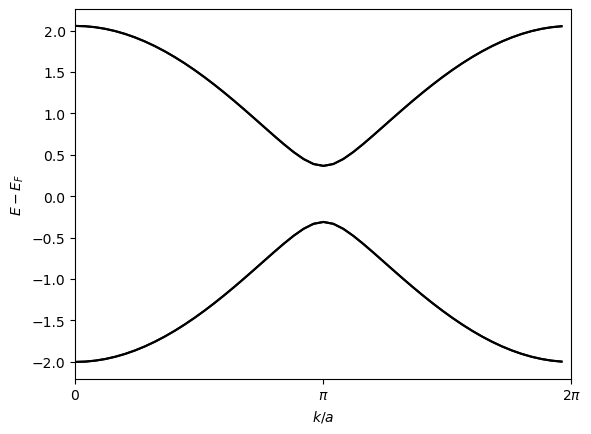

In [37]:
h_mf = meanfi.add_tb(h_0, mf_sol)

hamiltonians = meanfi.tb_to_kgrid(h_mf, nk)
vals, vecs = np.linalg.eigh(hamiltonians)
plt.plot(ks, vals, c="k")
plt.xticks([0, np.pi, 2 * np.pi], ["$0$", "$\pi$", "$2\pi$"])
plt.xlim(0, 2 * np.pi)
plt.ylabel("$E - E_F$")
plt.xlabel("$k / a$")
plt.show()

the band structure now shows a gap at the Fermi level, indicating that the system is in an insulating phase!


We can go further and compute the gap for a wider range of $U$ values:

<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
/var/folders/48/6y5gb3f12mzc7jw_vmbm6y0c0000gp/T/ipykernel_81592/2561915079.py:42: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta{E}/t$")


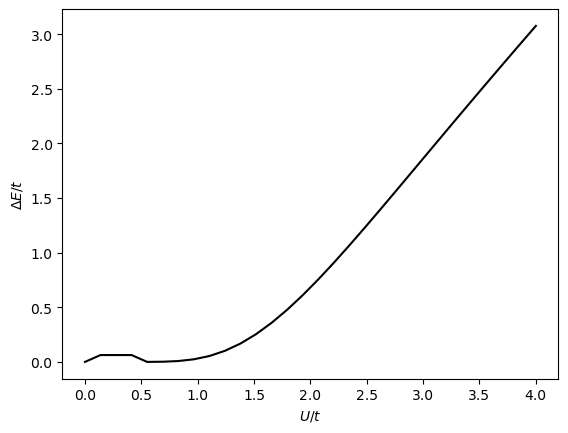

In [ ]:
def compute_sol(U, h_0, filling=2):
    h_int = {
        (0,): U * np.kron(np.eye(2), np.ones((2, 2))),
    }
    guess = meanfi.guess_tb(frozenset(h_int), len(list(h_0.values())[0]))
    full_model = meanfi.Model(h_0, h_int, filling, **tutorial_model_kwargs)
    mf_sol = meanfi.solver(
        full_model,
        guess,
        optimizer=anderson,
        optimizer_kwargs={"M": 0, "line_search": "wolfe", 'maxiter' : 10000, 'f_tol' : 1e-7},
    )
    return meanfi.add_tb(h_0, mf_sol)


def compute_gap(full_sol, nk_dense, fermi_energy=0):
    h_kgrid = meanfi.tb_to_kgrid(full_sol, nk_dense)
    vals = np.linalg.eigvalsh(h_kgrid)

    emax = np.max(vals[vals <= fermi_energy])
    emin = np.min(vals[vals > fermi_energy])
    return np.abs(emin - emax)


def compute_phase_diagram(
    Us,
    nk_dense,
):
    gaps = []
    for U in Us:
        full_sol = compute_sol(U, h_0)
        gaps.append(compute_gap(full_sol, nk_dense))

    return np.asarray(gaps, dtype=float)


Us = np.linspace(0, 4, 30, endpoint=True)
gaps = compute_phase_diagram(Us=Us, nk_dense=100)

plt.plot(Us, gaps, c="k")
plt.xlabel("$U / t$")
plt.ylabel("$\Delta{E}/t$")
plt.show()

We see that at around $U=1$ the gap opens up and the system transitions from a metal to an insulator.  In order to more accurately determine the size of the gap, we chose to use a denser k-grid for the diagonalization of the mean-field solution.